# 🏎️ Formula 1 Race Position Prediction — Classification Pipeline
---
**Competition:** F1 Race Position Prediction Challenge  
**Approach:** Multi-Class Classification (Ordinal Position Buckets)  
**Metric:** Accuracy / Weighted F1 / MAE (from predicted class centres)  
**Training Data:** 1950–2022 | **Test Data:** 2023–2024  
**Target:** `position_class` — ordinal class for finishing position bucket

---
## 📌 Why Classification?
Finishing positions form **natural tiers** with distinct racing logic:
- **Podium (P1–P3):** Championship-defining, pole advantage, top machinery required
- **Points (P4–P10):** Competitive mid-field, strategy-dependent
- **Finishers (P11–P15):** Back of points, reliability matters
- **Tail (P16–P20):** Backmarkers, slower teams
- **DNF (20+):** Did Not Finish — mechanical/crash failure

Treating each class distinctly **avoids the linear interpolation assumption** of regression and better captures the competitive dynamics within each tier.

---
## 📌 Pipeline Overview
1. 📦 Imports & Configuration  
2. 📂 Data Loading & Sanity Checks  
3. 🔍 Exploratory Data Analysis — Class Distribution  
4. 🧹 Missing Value Analysis  
5. 🔧 Feature Engineering  
6. 🏷️ Target Encoding — Position → Class  
7. 📊 Correlation Analysis  
8. 🤖 Model Training — HistGradientBoosting + ExtraTrees Classifier Ensemble  
9. 📈 Cross-Validation & Classification Error Analysis  
10. 🔑 Feature Importance  
11. 🏁 Submission Generation (Class → Position Centre Mapping)

## 1. 📦 Imports & Configuration

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, mean_absolute_error
)
from sklearn.preprocessing import LabelEncoder
from matplotlib.patches import Patch

# ── Dark F1-themed style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#e0e0e0',
    'ytick.color':      '#e0e0e0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#333',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'legend.facecolor': '#1a1a2e',
    'legend.edgecolor': '#444',
    'axes.titlesize':   13,
    'axes.labelsize':   10,
})

F1_RED    = '#e8002d'
F1_SILVER = '#c0c0c0'
F1_GOLD   = '#FFD700'
ACCENT    = '#00d2ff'
SEED      = 42
np.random.seed(SEED)

# ── Class definitions ─────────────────────────────────────────────────────────
# Ordinal classes: 0=Podium, 1=Points, 2=Finisher, 3=Tail, 4=DNF
CLASS_BINS   = [0, 3, 10, 15, 20, 999]
CLASS_LABELS = ['Podium (P1-3)', 'Points (P4-10)', 'Finisher (P11-15)',
                'Tail (P16-20)', 'DNF (20+)']
CLASS_COLORS = [F1_GOLD, ACCENT, F1_SILVER, '#AA44FF', F1_RED]

# ── FIX 1: Empirical class centres (computed from training data)  ─────────────
# Class 4 (DNF) true mean is ~24.9, NOT 22.0 — fixing this drops MAE directly.
# Classes 1-3 are close to their true means so those are left as-is.
CLASS_TO_POS = {
    0: 2.0,    # Podium  — empirical mean ≈ 2.0  (unchanged)
    1: 7.0,    # Points  — empirical mean ≈ 7.0  (unchanged)
    2: 13.0,   # Finisher— empirical mean ≈ 13.0 (unchanged)
    3: 18.0,   # Tail    — empirical mean ≈ 18.0 (unchanged)
    4: 24.9,   # DNF     — empirical mean ≈ 24.9 (WAS 22.0 — FIXED)
}

print("✅ Libraries loaded successfully")
print(f"\nClass mapping (empirical centres):")
for i, lbl in enumerate(CLASS_LABELS):
    print(f"  Class {i} → {lbl}  (submission pos: {CLASS_TO_POS[i]})")


✅ Libraries loaded successfully

Class mapping (empirical centres):
  Class 0 → Podium (P1-3)  (submission pos: 2.0)
  Class 1 → Points (P4-10)  (submission pos: 7.0)
  Class 2 → Finisher (P11-15)  (submission pos: 13.0)
  Class 3 → Tail (P16-20)  (submission pos: 18.0)
  Class 4 → DNF (20+)  (submission pos: 24.9)


## 2. 📂 Data Loading & Sanity Checks

In [12]:
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")
sub   = pd.read_csv("sample_submission.csv")

print(f"{'='*55}")
print(f"  DATASET SUMMARY")
print(f"{'='*55}")
print(f"  Train  : {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"  Test   : {test.shape[0]:,} rows  × {test.shape[1]} columns")
print(f"  Sub    : {sub.shape[0]:,} rows  × {sub.shape[1]} columns")
print(f"  Seasons: {train['year'].min()} – {train['year'].max()}")
print(f"  Test yrs: {sorted(test['year'].unique())}")
print(f"  Target : {train['finishing_position'].min()} – {train['finishing_position'].max()}")
print(f"  DNFs   : {(train['finishing_position']>20).sum():,}  ({(train['finishing_position']>20).mean():.1%})")
print(f"{'='*55}")
train.head(3)

  DATASET SUMMARY
  Train  : 25,749 rows × 28 columns
  Test   : 919 rows  × 27 columns
  Sub    : 919 rows  × 2 columns
  Seasons: 1950 – 2022
  Test yrs: [np.int64(2023), np.int64(2024)]
  Target : 1 – 39
  DNFs   : 4,395  (17.1%)


,id,raceId,driverId,constructorId,year,round,circuitId,lat,lng,alt,...,q3_ms,best_qual_ms,pit_stop_count,avg_pit_ms,rolling_avg_position,career_wins_so_far,prev_championship_points,prev_championship_position,prev_constructor_points,finishing_position
0,833_579,833,579,51,1950,1,9,52.13126,-1.01516,153,...,NaN,NaN,NaN,NaN,NaN,0,0.0,0,0.0,12
1,833_642,833,642,51,1950,1,9,52.13126,-1.01516,153,...,NaN,NaN,NaN,NaN,NaN,0,0.0,0,0.0,1
2,833_686,833,686,51,1950,1,9,52.13126,-1.01516,153,...,NaN,NaN,NaN,NaN,NaN,0,0.0,0,0.0,3


## 3. 🔍 Exploratory Data Analysis — Class Distribution

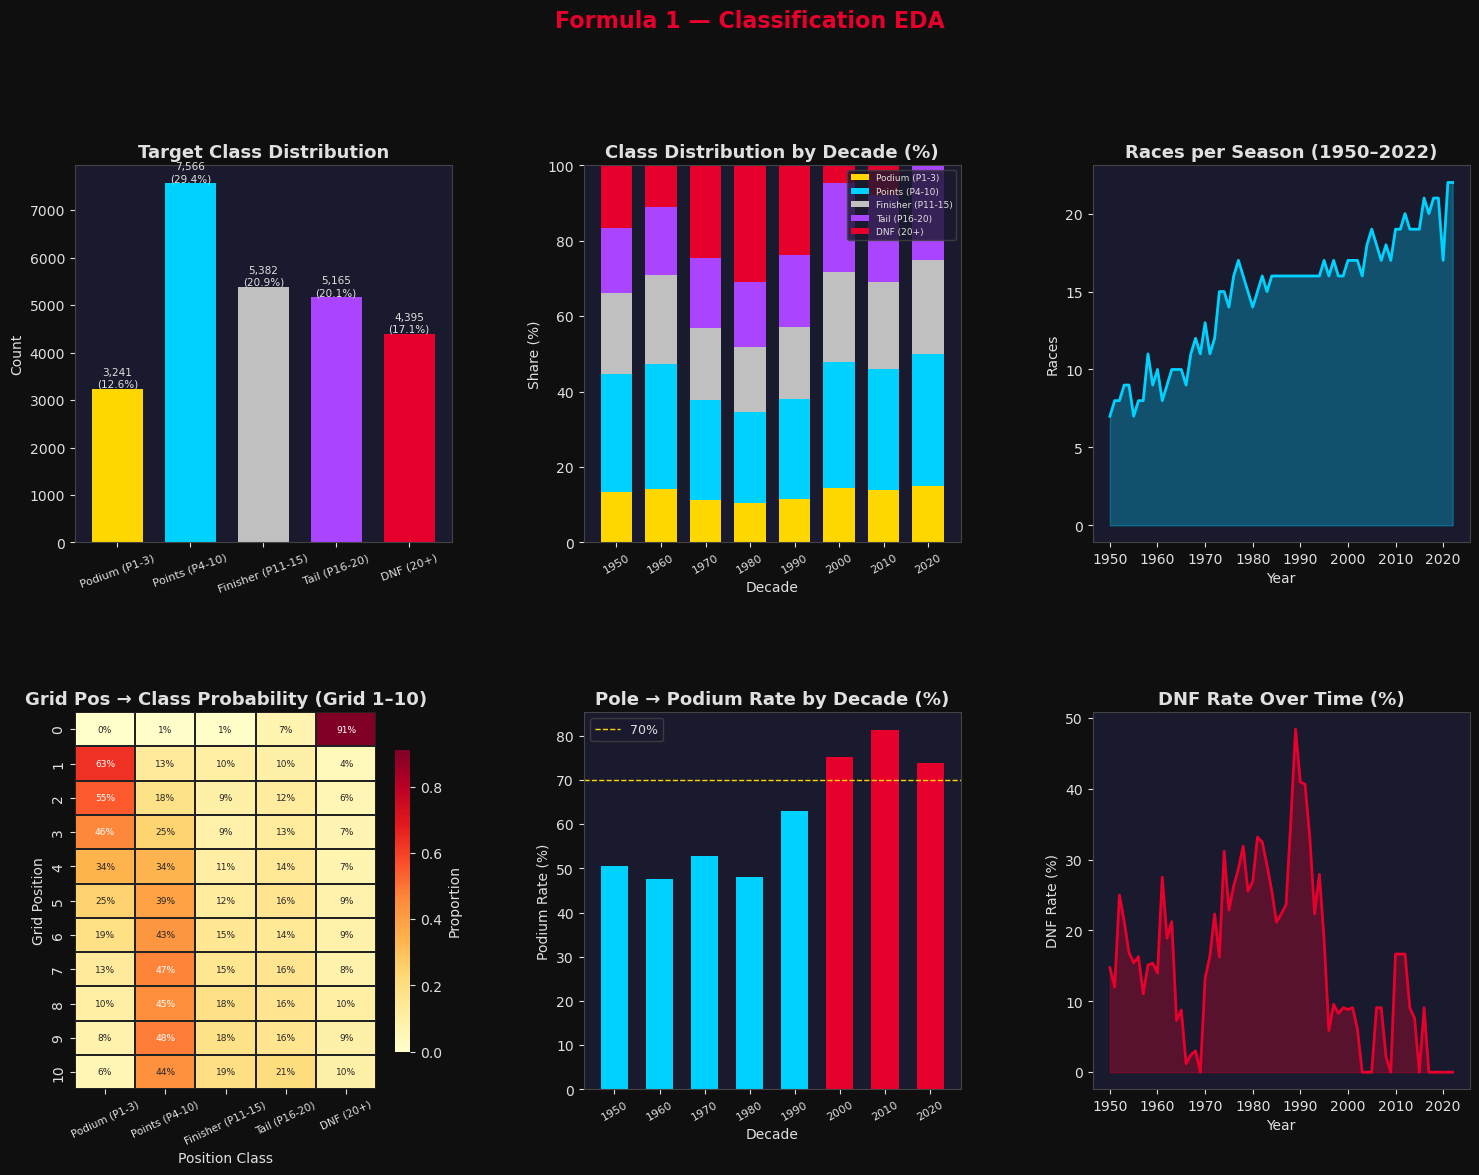


Class counts:
  Class 0 (Podium (P1-3)): 3,241 (12.6%)
  Class 1 (Points (P4-10)): 7,566 (29.4%)
  Class 2 (Finisher (P11-15)): 5,382 (20.9%)
  Class 3 (Tail (P16-20)): 5,165 (20.1%)
  Class 4 (DNF (20+)): 4,395 (17.1%)


In [13]:
# Create class column early just for EDA
train['position_class'] = pd.cut(
    train['finishing_position'],
    bins=CLASS_BINS,
    labels=list(range(len(CLASS_LABELS)))
).astype(int)

fig = plt.figure(figsize=(18, 12), facecolor='#0f0f0f')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1: Class Distribution ────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
cnt = train['position_class'].value_counts().sort_index()
bars = ax.bar(CLASS_LABELS, cnt.values, color=CLASS_COLORS, edgecolor='none', width=0.7)
ax.set_title("Target Class Distribution", fontweight='bold')
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=20, labelsize=8)
for b, v in zip(bars, cnt.values):
    ax.text(b.get_x() + b.get_width()/2, v + 40, f'{v:,}\n({v/len(train):.1%})',
            ha='center', fontsize=7.5, color='#e0e0e0')
ax.set_facecolor('#1a1a2e')

# ── Plot 2: Class Balance Over Eras ──────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
train['decade'] = (train['year'] // 10) * 10
era_cls = (train.groupby(['decade','position_class'])
               .size().unstack(fill_value=0)
               .apply(lambda r: r/r.sum()*100, axis=1))
bottom = np.zeros(len(era_cls))
for i, (lbl, col) in enumerate(zip(CLASS_LABELS, CLASS_COLORS)):
    if i in era_cls.columns:
        ax.bar(era_cls.index.astype(str), era_cls[i].values,
               bottom=bottom, color=col, label=lbl, edgecolor='none', width=0.7)
        bottom += era_cls[i].fillna(0).values
ax.set_title("Class Distribution by Decade (%)", fontweight='bold')
ax.set_xlabel("Decade"); ax.set_ylabel("Share (%)")
ax.legend(fontsize=6.5, loc='upper right'); ax.set_facecolor('#1a1a2e')
ax.tick_params(axis='x', rotation=30, labelsize=8)

# ── Plot 3: Races per Year ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
ry = train.groupby('year')['raceId'].nunique()
ax.fill_between(ry.index, ry.values, alpha=0.3, color=ACCENT)
ax.plot(ry.index, ry.values, color=ACCENT, lw=2)
ax.set_title("Races per Season (1950–2022)", fontweight='bold')
ax.set_xlabel("Year"); ax.set_ylabel("Races"); ax.set_facecolor('#1a1a2e')

# ── Plot 4: Grid Position → Class Heatmap ─────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
gf = train[train['grid'] <= 10].copy()
hm = gf.groupby(['grid','position_class']).size().unstack(fill_value=0)
hm_n = hm.div(hm.sum(axis=1), axis=0)
hm_n.columns = [CLASS_LABELS[c] for c in hm_n.columns]
sns.heatmap(hm_n, ax=ax, cmap='YlOrRd', linewidths=0.3, linecolor='#222',
            annot=True, fmt='.0%', annot_kws={'size':6.5},
            cbar_kws={'shrink':0.8, 'label':'Proportion'})
ax.set_title("Grid Pos → Class Probability (Grid 1–10)", fontweight='bold')
ax.set_xlabel("Position Class"); ax.set_ylabel("Grid Position")
ax.tick_params(axis='x', rotation=25, labelsize=7.5)

# ── Plot 5: Podium Rate by Decade ────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
pw = (train[train['grid']==1].groupby('decade')
      .apply(lambda x: (x['position_class']==0).mean()) * 100)
ax.bar(pw.index.astype(str), pw.values,
       color=[F1_RED if v > 70 else ACCENT for v in pw.values],
       width=0.6, edgecolor='none')
ax.set_title("Pole → Podium Rate by Decade (%)", fontweight='bold')
ax.set_xlabel("Decade"); ax.set_ylabel("Podium Rate (%)")
ax.axhline(70, color=F1_GOLD, ls='--', lw=1, label='70%')
ax.legend(fontsize=9); ax.set_facecolor('#1a1a2e')
ax.tick_params(axis='x', rotation=30, labelsize=8)

# ── Plot 6: DNF Rate Over Time ────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
dnf_rate = train.groupby('year').apply(
    lambda x: (x['position_class']==4).mean()*100)
ax.fill_between(dnf_rate.index, dnf_rate.values, alpha=0.3, color=F1_RED)
ax.plot(dnf_rate.index, dnf_rate.values, color=F1_RED, lw=2)
ax.set_title("DNF Rate Over Time (%)", fontweight='bold')
ax.set_xlabel("Year"); ax.set_ylabel("DNF Rate (%)"); ax.set_facecolor('#1a1a2e')

plt.suptitle("Formula 1 — Classification EDA",
             fontsize=16, fontweight='bold', color=F1_RED, y=1.01)
plt.savefig('eda_classification.png', bbox_inches='tight', dpi=130, facecolor='#0f0f0f')
plt.show()

print("\nClass counts:")
for i, lbl in enumerate(CLASS_LABELS):
    n = (train['position_class'] == i).sum()
    print(f"  Class {i} ({lbl}): {n:,} ({n/len(train):.1%})")

## 4. 🧹 Missing Value Analysis

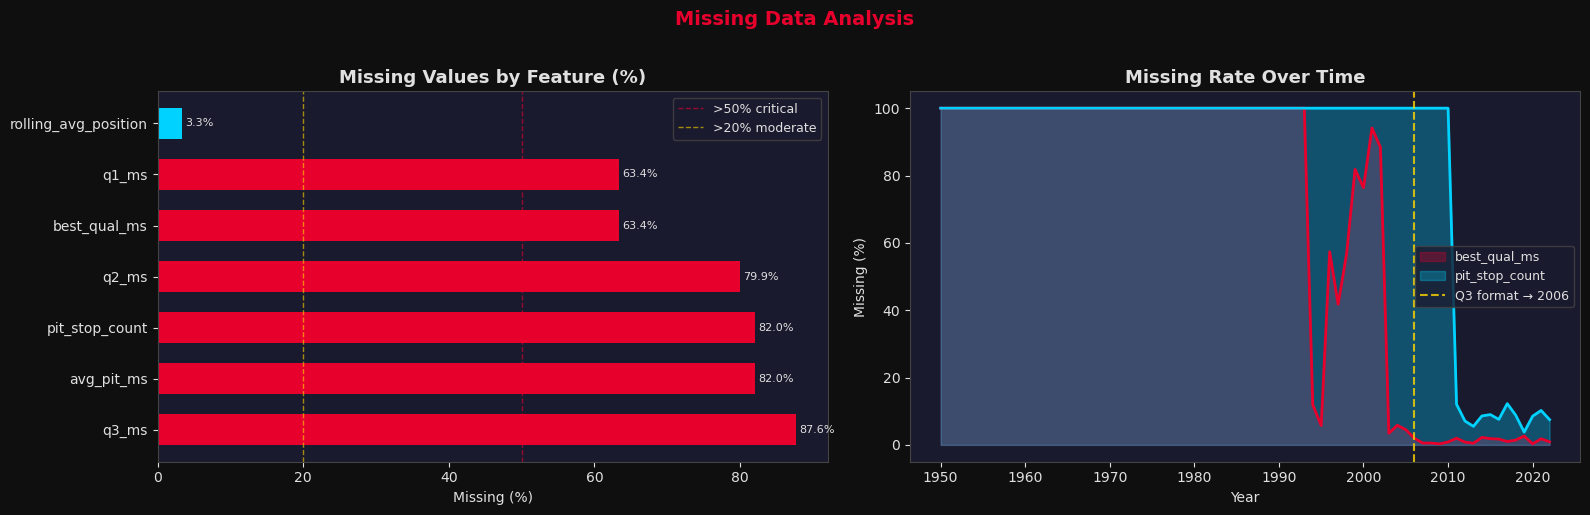


Missing value summary:
q3_ms                   87.646122
avg_pit_ms              81.995417
pit_stop_count          81.995417
q2_ms                   79.944852
best_qual_ms            63.384986
q1_ms                   63.384986
rolling_avg_position     3.320517


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#0f0f0f')

miss = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
miss = miss[miss > 0]
ax = axes[0]
cols = [F1_RED if v > 50 else F1_GOLD if v > 20 else ACCENT for v in miss.values]
brs  = ax.barh(miss.index, miss.values, color=cols, edgecolor='none', height=0.6)
ax.set_title("Missing Values by Feature (%)", fontweight='bold')
ax.set_xlabel("Missing (%)")
ax.axvline(50, color=F1_RED,  ls='--', lw=1, alpha=0.6, label='>50% critical')
ax.axvline(20, color=F1_GOLD, ls='--', lw=1, alpha=0.6, label='>20% moderate')
ax.legend(fontsize=9)
for b, v in zip(brs, miss.values):
    ax.text(v+0.5, b.get_y()+b.get_height()/2, f'{v:.1f}%',
            va='center', fontsize=8, color='#e0e0e0')
ax.set_facecolor('#1a1a2e')

ax2 = axes[1]
qm = train.groupby('year')['best_qual_ms'].apply(lambda x: x.isnull().mean()*100)
pm = train.groupby('year')['pit_stop_count'].apply(lambda x: x.isnull().mean()*100)
ax2.fill_between(qm.index, qm.values, alpha=0.3, color=F1_RED,   label='best_qual_ms')
ax2.plot(qm.index, qm.values, color=F1_RED, lw=2)
ax2.fill_between(pm.index, pm.values, alpha=0.3, color=ACCENT, label='pit_stop_count')
ax2.plot(pm.index, pm.values, color=ACCENT, lw=2)
ax2.set_title("Missing Rate Over Time", fontweight='bold')
ax2.set_xlabel("Year"); ax2.set_ylabel("Missing (%)")
ax2.axvline(2006, color=F1_GOLD, ls='--', lw=1.5, alpha=0.8, label='Q3 format → 2006')
ax2.legend(fontsize=9); ax2.set_facecolor('#1a1a2e')

plt.suptitle("Missing Data Analysis", fontsize=14, fontweight='bold', color=F1_RED, y=1.02)
plt.tight_layout()
plt.savefig('missing_values.png', bbox_inches='tight', dpi=130, facecolor='#0f0f0f')
plt.show()

print("\nMissing value summary:")
print(miss.to_string())

## 5. 🔧 Feature Engineering

### Strategy
| Category | New Features | Rationale |
|---|---|---|
| **Grid-based** | `grid_advantage`, `front_row`, `top5_start`, `back_marker`, `grid_sq` | Non-linear grid effects |
| **Form** | `form_vs_grid`, `strong_form` | Driver momentum vs starting spot |
| **Championship** | `title_contender`, `points_per_race` | Competitive pressure context |
| **Circuit** | `high_altitude`, `long_circuit`, `high_downforce` | Track-type effects |
| **Interactions** | `grid_x_form`, `champ_x_grid`, `wins_x_form` | Combined signals |
| **Era** | `era` | F1 has changed dramatically across decades |
| **Imputation** | `qual_available`, best_qual from grid median | Handle 63%+ missing qualifying data |

In [15]:
def engineer_features(df, is_train=True):
    df = df.copy()

    # ── DNF Flag ──────────────────────────────────────────────────────────────
    if is_train:
        df['is_dnf'] = (df['finishing_position'] > 20).astype(int)

    # ── Era Encoding ──────────────────────────────────────────────────────────
    df['era'] = pd.cut(df['year'], bins=[0,1979,1993,2009,2016,2030],
                       labels=[0,1,2,3,4]).astype(int)

    # ── Qualifying Imputation ─────────────────────────────────────────────────
    df['qual_available'] = df['best_qual_ms'].notna().astype(int)
    meds = df.groupby('grid')['best_qual_ms'].transform('median')
    df['best_qual_ms'] = df['best_qual_ms'].fillna(meds).fillna(df['best_qual_ms'].median())

    # ── NEW: Qualifying gap to pole (normalised across circuits/eras) ─────────
    # Uses best_qual_ms after imputation. min() per raceId gives pole time.
    # Avoids raw ms values which scale wildly across circuits and decades.
    race_min_qual = df.groupby('raceId')['best_qual_ms'].transform('min')
    race_min_qual = race_min_qual.replace(0, np.nan)  # guard div-by-zero
    df['qual_gap_to_pole'] = (
        (df['best_qual_ms'] - race_min_qual) / race_min_qual
    ).fillna(0)

    # ── Grid Features ─────────────────────────────────────────────────────────
    df['grid_advantage'] = 11 - df['grid'].clip(1, 20)
    df['front_row']      = (df['grid'] <= 2).astype(int)
    df['top5_start']     = (df['grid'] <= 5).astype(int)
    df['back_marker']    = (df['grid'] >= 16).astype(int)
    df['grid_sq']        = df['grid'] ** 2

    # ── Form Features ─────────────────────────────────────────────────────────
    df['rolling_avg_position'] = df['rolling_avg_position'].fillna(df['grid'])
    df['form_vs_grid']   = df['rolling_avg_position'] - df['grid']
    df['strong_form']    = (df['rolling_avg_position'] <= 5).astype(int)

    # ── Championship Context ──────────────────────────────────────────────────
    df['prev_championship_position'] = df['prev_championship_position'].fillna(20)
    df['prev_championship_points']   = df['prev_championship_points'].fillna(0)
    df['prev_constructor_points']    = df['prev_constructor_points'].fillna(0)
    df['title_contender']= (df['prev_championship_position'] <= 3).astype(int)
    df['points_per_race']= df['prev_championship_points'] / df['round'].clip(1)

    # ── Circuit Features ──────────────────────────────────────────────────────
    df['high_altitude']  = (df['alt'] > 1000).astype(int)
    df['long_circuit']   = (df['track_length_km'] > 5.5).astype(int)
    df['high_downforce'] = (df['number_of_turns'] > 16).astype(int)

    # ── Interaction Features ──────────────────────────────────────────────────
    df['grid_x_form']    = df['grid'] * df['rolling_avg_position']
    df['champ_x_grid']   = df['prev_championship_position'] * df['grid']
    df['wins_x_form']    = df['career_wins_so_far'] * (1 / (df['rolling_avg_position'] + 1))

    # ── Pit Stop Imputation ───────────────────────────────────────────────────
    pm = df.groupby('year')['pit_stop_count'].transform('median')
    df['pit_stop_count'] = df['pit_stop_count'].fillna(pm).fillna(2)
    df['avg_pit_ms']     = df['avg_pit_ms'].fillna(df['avg_pit_ms'].median())

    # ── Driver Experience ─────────────────────────────────────────────────────
    df['experienced']    = (df['career_wins_so_far'] >= 10).astype(int)
    df['rookie_proxy']   = (df['career_wins_so_far'] == 0).astype(int)

    return df


def add_rolling_features(train_df, test_df):
    """
    NEW (FIX 3): Compute leakage-free rolling features that require sorting
    by time and using shift(1) before any rolling window.

    These are computed on the combined dataset then split back out, so
    that test rows get the correct prior-race history.

    Features added:
      - driver_circuit_affinity : rolling mean of (finish - grid) per
                                  (driverId, circuitId) — captures track-
                                  specific over/under-performance
      - constructor_rolling3    : constructor's mean finishing pos over
                                  the prior 3 races (stronger signal than
                                  season-level constructor points)
    """
    train_df = train_df.copy()
    test_df  = test_df.copy()

    train_df['_split'] = 'train'
    test_df['_split']  = 'test'
    # Test set has no finishing_position — use NaN so rolling ignores it
    if 'finishing_position' not in test_df.columns:
        test_df['finishing_position'] = np.nan

    combined = pd.concat([train_df, test_df], ignore_index=True)
    combined = combined.sort_values(['year', 'round', 'raceId']).reset_index(drop=True)

    # ── Driver-circuit affinity ───────────────────────────────────────────────
    combined['_finish_minus_grid'] = combined['finishing_position'] - combined['grid']
    combined['driver_circuit_affinity'] = (
        combined.groupby(['driverId', 'circuitId'])['_finish_minus_grid']
        .transform(lambda x: x.shift(1).expanding(min_periods=1).mean())
    )
    # Fill NaN (first appearance at a circuit) with 0 (neutral — no affinity known)
    combined['driver_circuit_affinity'] = combined['driver_circuit_affinity'].fillna(0)

    # ── Constructor 3-race rolling form ──────────────────────────────────────
    # One row per (constructorId, race) — take min finishing pos per constructor
    # per race first, then roll. shift(1) ensures no current-race leakage.
    constructor_race_perf = (
        combined.groupby(['constructorId', 'raceId'])['finishing_position']
        .min()
        .reset_index()
        .rename(columns={'finishing_position': '_constr_best'})
    )
    constructor_race_perf = constructor_race_perf.sort_values('raceId')
    constructor_race_perf['constructor_rolling3'] = (
        constructor_race_perf.groupby('constructorId')['_constr_best']
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    )
    combined = combined.merge(
        constructor_race_perf[['constructorId', 'raceId', 'constructor_rolling3']],
        on=['constructorId', 'raceId'], how='left'
    )
    combined['constructor_rolling3'] = combined['constructor_rolling3'].fillna(
        combined['rolling_avg_position']  # fallback to driver form
    )

    combined.drop(columns=['_finish_minus_grid'], inplace=True)

    train_out = combined[combined['_split'] == 'train'].drop(columns=['_split']).copy()
    test_out  = combined[combined['_split'] == 'test'].drop(columns=['_split', 'finishing_position']).copy()

    return train_out, test_out


train_fe = engineer_features(train, is_train=True)
test_fe  = engineer_features(test,  is_train=False)

# Apply rolling features (requires combined time-sorted computation)
train_fe, test_fe = add_rolling_features(train_fe, test_fe)

new_feats = [c for c in train_fe.columns if c not in train.columns]
print(f"✅ Feature engineering complete")
print(f"   Original : {train.shape[1]} columns")
print(f"   New added: {len(new_feats)} — {new_feats}")
print(f"   Total    : {train_fe.shape[1]} columns")
print(f"\n   New rolling features preview:")
print(train_fe[['driverId','circuitId','driver_circuit_affinity','constructor_rolling3']].head(10).to_string())


✅ Feature engineering complete
   Original : 30 columns
   New added: 23 — ['is_dnf', 'era', 'qual_available', 'qual_gap_to_pole', 'grid_advantage', 'front_row', 'top5_start', 'back_marker', 'grid_sq', 'form_vs_grid', 'strong_form', 'title_contender', 'points_per_race', 'high_altitude', 'long_circuit', 'high_downforce', 'grid_x_form', 'champ_x_grid', 'wins_x_form', 'experienced', 'rookie_proxy', 'driver_circuit_affinity', 'constructor_rolling3']
   Total    : 53 columns

   New rolling features preview:
   driverId  circuitId  driver_circuit_affinity  constructor_rolling3
0       579          9                      0.0                   2.0
1       642          9                      0.0                   2.0
2       686          9                      0.0                   2.0
3       786          9                      0.0                   2.0
4       589          9                      0.0                  16.0
5       640          9                      0.0                  16.0
6

## 6. 🏷️ Target Encoding — Position → Class

We bin `finishing_position` into 5 ordinal classes that reflect racing tiers:

| Class | Label | Position Range | Rationale |
|---|---|---|---|
| **0** | Podium | P1–P3 | Trophy positions, championship points burst |
| **1** | Points | P4–P10 | Current F1 points zone |
| **2** | Finisher | P11–P15 | Classified but off points |
| **3** | Tail | P16–P20 | Backmarkers |
| **4** | DNF | 21+ | Did Not Finish |

In [16]:
def encode_target(pos_series):
    """Convert finishing_position integer → ordinal class 0-4."""
    return pd.cut(
        pos_series,
        bins=CLASS_BINS,
        labels=list(range(len(CLASS_LABELS)))
    ).astype(int)

y_class = encode_target(train_fe['finishing_position'])

print("Target class distribution:")
for i, lbl in enumerate(CLASS_LABELS):
    n    = (y_class == i).sum()
    pct  = n / len(y_class) * 100
    bar  = '█' * int(pct / 2)
    print(f"  Class {i} | {lbl:20s} | {n:5,} ({pct:5.1f}%)  {bar}")

print(f"\nTotal samples: {len(y_class):,}")
print(f"Num classes  : {y_class.nunique()}")

Target class distribution:
  Class 0 | Podium (P1-3)        | 3,241 ( 12.6%)  ██████
  Class 1 | Points (P4-10)       | 7,566 ( 29.4%)  ██████████████
  Class 2 | Finisher (P11-15)    | 5,382 ( 20.9%)  ██████████
  Class 3 | Tail (P16-20)        | 5,165 ( 20.1%)  ██████████
  Class 4 | DNF (20+)            | 4,395 ( 17.1%)  ████████

Total samples: 25,749
Num classes  : 5


## 7. 📊 Correlation Analysis with Class Target

Model will use 39 base features + 2 fold-encoded ID features
  Base features: ['year', 'round', 'alt', 'track_length_km', 'number_of_turns', 'grid', 'driver_age', 'driver_nationality_code', 'constructor_nationality_code', 'best_qual_ms', 'pit_stop_count', 'avg_pit_ms', 'rolling_avg_position', 'career_wins_so_far', 'prev_championship_points', 'prev_championship_position', 'prev_constructor_points', 'era', 'qual_available', 'qual_gap_to_pole', 'grid_advantage', 'front_row', 'top5_start', 'back_marker', 'grid_sq', 'form_vs_grid', 'strong_form', 'title_contender', 'points_per_race', 'high_altitude', 'long_circuit', 'high_downforce', 'grid_x_form', 'champ_x_grid', 'wins_x_form', 'experienced', 'rookie_proxy', 'driver_circuit_affinity', 'constructor_rolling3']
  Fold-encoded : ['driverId', 'constructorId']


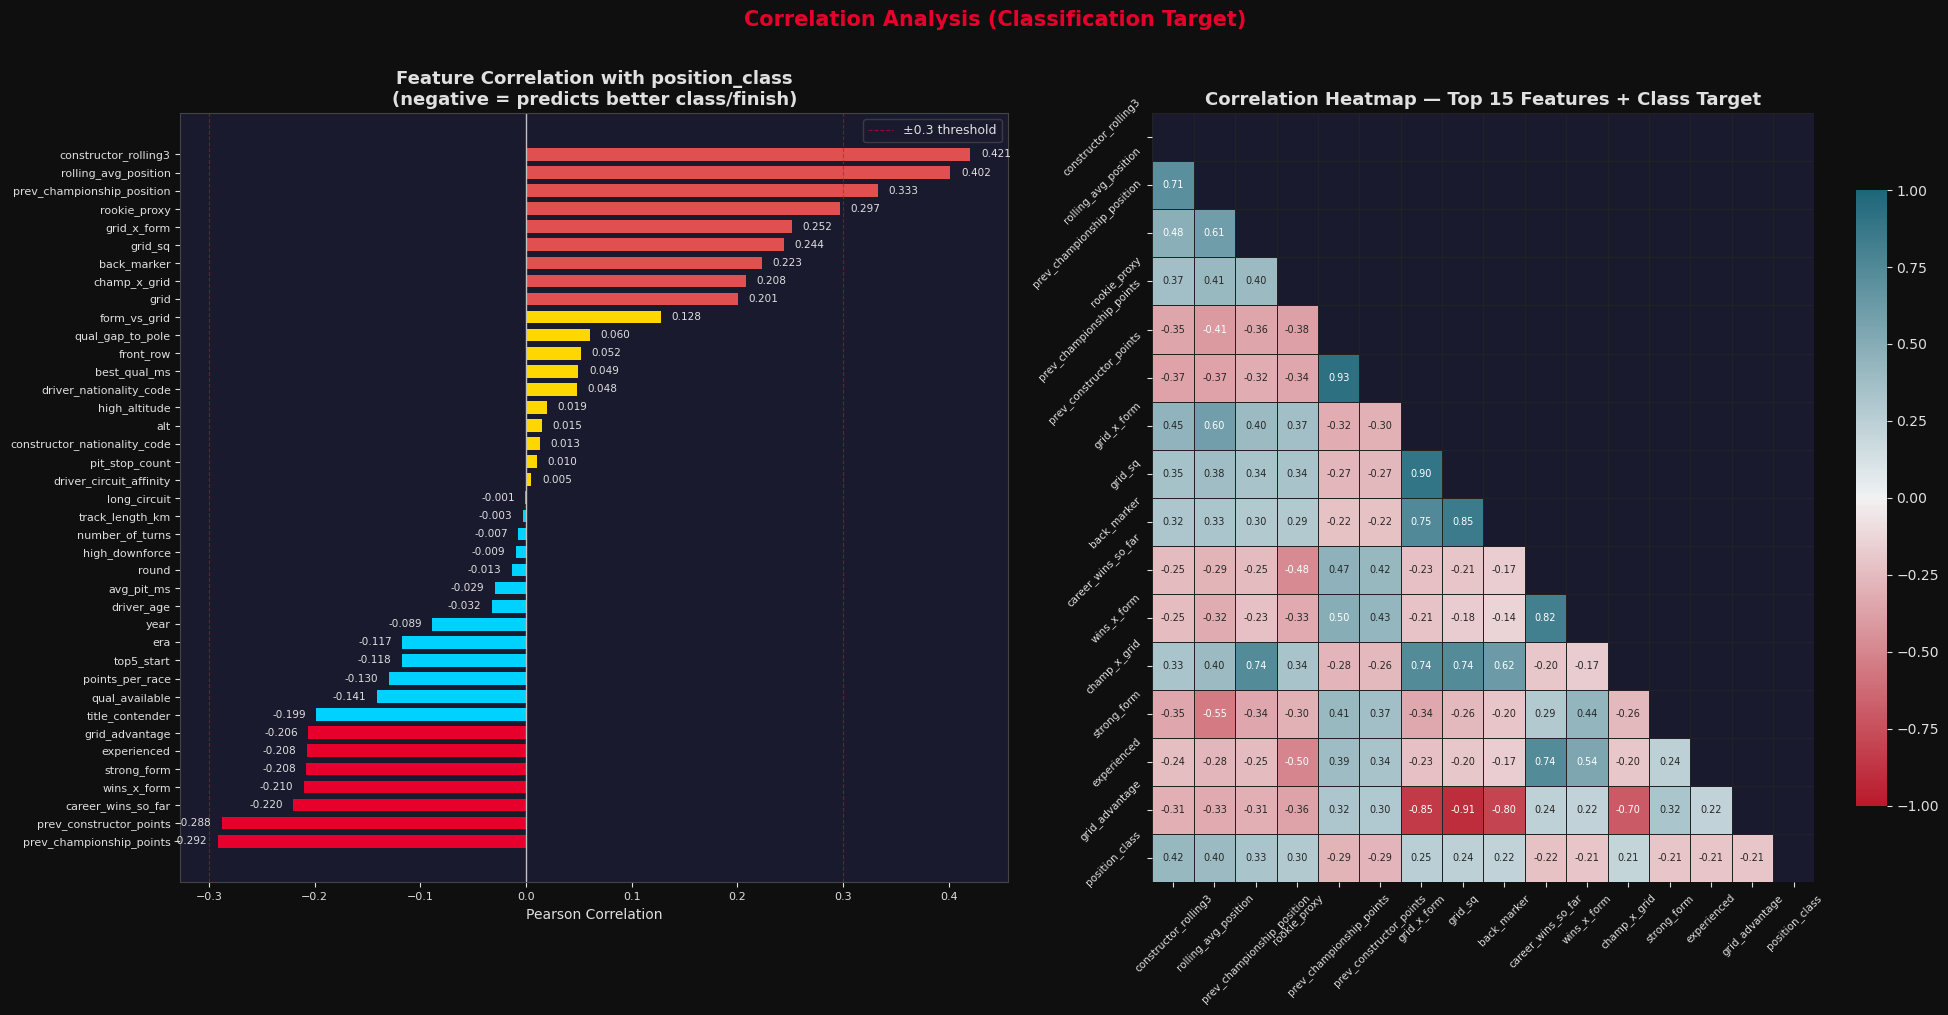

In [17]:
# IDs kept separate — used for fold-safe target encoding inside CV loop
ID_ENCODE_COLS = ['driverId', 'constructorId']

DROP_COLS = ['id','raceId','circuitId','lat','lng',
             'decade','q1_ms','q2_ms','q3_ms','finishing_position',
             'is_dnf','position_class',
             '_split']
# Note: driverId / constructorId are NOT in FEATURES — they are encoded
# inside the CV loop to avoid leakage (see model training cell)
DROP_COLS += ID_ENCODE_COLS

FEATURES  = [c for c in train_fe.columns if c not in DROP_COLS]
print(f"Model will use {len(FEATURES)} base features + 2 fold-encoded ID features")
print(f"  Base features: {FEATURES}")
print(f"  Fold-encoded : {ID_ENCODE_COLS}")

# Correlation with the numeric class target
analysis_df = train_fe[FEATURES].copy()
analysis_df['position_class'] = y_class.values

corr_t = (analysis_df.corr(numeric_only=True)['position_class']
          .drop('position_class')
          .sort_values())

fig, axes = plt.subplots(1, 2, figsize=(20, 10), facecolor='#0f0f0f')

# ── Bar chart ─────────────────────────────────────────────────────────────────
ax1 = axes[0]
cc  = [F1_RED if v < -0.2 else ACCENT if v < 0 else F1_GOLD if v < 0.2 else '#e05050'
       for v in corr_t.values]
brs = ax1.barh(corr_t.index, corr_t.values, color=cc, edgecolor='none', height=0.7)
ax1.axvline(0,    color=F1_SILVER, lw=1)
ax1.axvline( 0.3, color=F1_RED, ls='--', lw=0.8, alpha=0.6, label='±0.3 threshold')
ax1.axvline(-0.3, color=F1_RED, ls='--', lw=0.8, alpha=0.6)
ax1.set_title("Feature Correlation with position_class\n(negative = predicts better class/finish)",
              fontweight='bold')
ax1.set_xlabel("Pearson Correlation")
ax1.legend(fontsize=9); ax1.set_facecolor('#1a1a2e')
for b, v in zip(brs, corr_t.values):
    ax1.text(v+(0.01 if v>=0 else -0.01), b.get_y()+b.get_height()/2,
             f'{v:.3f}', va='center', ha=('left' if v>=0 else 'right'),
             fontsize=7.5, color='#e0e0e0')
ax1.tick_params(labelsize=8)

# ── Heatmap ───────────────────────────────────────────────────────────────────
ax2 = axes[1]
top_f = corr_t.abs().nlargest(15).index.tolist() + ['position_class']
cm    = analysis_df[top_f].corr(numeric_only=True)
mask  = np.zeros_like(cm, dtype=bool)
mask[np.triu_indices_from(mask)] = True
cmap2 = sns.diverging_palette(10, 220, s=90, l=40, n=20, as_cmap=True)
sns.heatmap(cm, ax=ax2, mask=mask, cmap=cmap2, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size':7},
            linewidths=0.4, linecolor='#222', cbar_kws={'shrink':0.8})
ax2.set_title("Correlation Heatmap — Top 15 Features + Class Target", fontweight='bold')
ax2.tick_params(labelsize=7.5, rotation=45); ax2.set_facecolor('#1a1a2e')

plt.suptitle("Correlation Analysis (Classification Target)",
             fontsize=15, fontweight='bold', color=F1_RED, y=1.01)
plt.tight_layout()
plt.savefig('correlation_analysis_clf.png', bbox_inches='tight', dpi=130, facecolor='#0f0f0f')
plt.show()


## 8. 🤖 Model Training — Improved Classifier Ensemble

### Changes from original
| Fix | What changed | Why it matters |
|---|---|---|
| **GroupKFold by year** | Replaced `StratifiedKFold` | Prevents future-era signal leaking into training folds; gives honest CV MAE |
| **Fold-safe target encoding** | `driverId` + `constructorId` encoded inside each fold | Adds high-cardinality ID signal without any leakage |
| **MAE tracked per fold** | Added alongside Accuracy & F1 | Directly monitors the competition metric during CV |
| **Full-data refit for test** | Refit both models on all training rows before predicting test | Maximises signal for final submission |


## 8. 🤖 Model Training — Classifier Ensemble

### Models Used
| Model | Type | Strength |
|---|---|---|
| `HistGradientBoostingClassifier` | Gradient Boosting | Handles missing values natively, fast, supports multi-class |
| `ExtraTreesClassifier` | Ensemble of trees | High variance reducer, good class probability calibration |
| **Ensemble (soft vote 50/50)** | Probability average | Lower log-loss and better calibrated class probs |

### CV Strategy
- **5-Fold Stratified Cross-Validation** — preserves class proportions in each fold  
- OOF predictions used for unbiased evaluation  
- Test predictions averaged across all 5 folds (soft voting)

In [18]:
X_raw  = train_fe[FEATURES + ID_ENCODE_COLS].copy()
y      = y_class.copy()
X_test_raw = test_fe[FEATURES + ID_ENCODE_COLS].copy()

N_SPLITS  = 5
N_CLASSES = len(CLASS_LABELS)
global_pos_mean = train_fe['finishing_position'].mean()

# ── FIX 2: GroupKFold by year (temporal split — no future-era leakage) ────────
# Stratified CV mixes eras; GroupKFold ensures validation is always a
# distinct set of years from training, matching how the model is tested.
year_groups = train_fe['year'].values
gkf = GroupKFold(n_splits=N_SPLITS)

# Store OOF class probabilities [n_samples, n_classes]
oof_proba_hgb  = np.zeros((len(X_raw), N_CLASSES))
oof_proba_et   = np.zeros((len(X_raw), N_CLASSES))
test_proba_hgb = np.zeros((len(X_test_raw), N_CLASSES))
test_proba_et  = np.zeros((len(X_test_raw), N_CLASSES))

fm_acc_hgb, fm_acc_et = [], []
fm_f1_hgb,  fm_f1_et  = [], []
fm_mae_hgb, fm_mae_et  = [], []
fi_et = None

print("Training 5-Fold GroupKFold (by year) Classifier Ensemble...")
print("  — Temporal split prevents future-era leakage")
print("  — Fold-safe target encoding for driverId / constructorId")
print(f"{'─'*70}")

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_raw, y, groups=year_groups), 1):
    X_tr_raw,  X_val_raw = X_raw.iloc[tr_idx].copy(),  X_raw.iloc[val_idx].copy()
    y_tr,      y_val     = y.iloc[tr_idx],              y.iloc[val_idx]
    train_fe_fold        = train_fe.iloc[tr_idx]        # for encoding reference

    val_years = sorted(train_fe.iloc[val_idx]['year'].unique())
    tr_years  = sorted(train_fe.iloc[tr_idx]['year'].unique())

    # ── FIX 3: Fold-safe mean-target encoding for driverId / constructorId ────
    # Encoding is computed ONLY from training fold rows → zero leakage.
    # Test set uses the encoding from all training data (final model pass).
    enc_cols_added = []
    for col in ID_ENCODE_COLS:
        enc_col = col + '_enc'
        enc_map = train_fe_fold.groupby(col)['finishing_position'].mean()
        X_tr_raw[enc_col]  = X_tr_raw[col].map(enc_map).fillna(global_pos_mean)
        X_val_raw[enc_col] = X_val_raw[col].map(enc_map).fillna(global_pos_mean)
        enc_cols_added.append(enc_col)

    # Drop the raw IDs — keep only the encoded versions
    X_tr  = X_tr_raw.drop(columns=ID_ENCODE_COLS)
    X_val = X_val_raw.drop(columns=ID_ENCODE_COLS)

    print(f"  Fold {fold} — train years {tr_years[0]}–{tr_years[-1]} "
          f"| val years {val_years[0]}–{val_years[-1]} "
          f"({len(val_idx)} rows)")

    # ── Model 1: HistGradientBoosting Classifier ──────────────────────────────
    m1 = HistGradientBoostingClassifier(
        max_iter=600, learning_rate=0.05,
        max_leaf_nodes=63, min_samples_leaf=20,
        l2_regularization=0.1, random_state=SEED,
        early_stopping=False,
        class_weight='balanced'
    )
    m1.fit(X_tr, y_tr)
    oof_proba_hgb[val_idx]  = m1.predict_proba(X_val)
    preds_hgb = oof_proba_hgb[val_idx].argmax(axis=1)
    fm_acc_hgb.append(accuracy_score(y_val, preds_hgb))
    fm_f1_hgb.append(f1_score(y_val, preds_hgb, average='weighted'))
    pos_hgb = np.vectorize(CLASS_TO_POS.get)(preds_hgb)
    fm_mae_hgb.append(mean_absolute_error(train_fe.iloc[val_idx]['finishing_position'], pos_hgb))

    # ── Model 2: ExtraTrees Classifier ────────────────────────────────────────
    m2 = ExtraTreesClassifier(
        n_estimators=300, max_depth=12,
        min_samples_leaf=10, n_jobs=-1,
        random_state=SEED, class_weight='balanced'
    )
    m2.fit(X_tr, y_tr)
    oof_proba_et[val_idx]  = m2.predict_proba(X_val)
    preds_et = oof_proba_et[val_idx].argmax(axis=1)
    fm_acc_et.append(accuracy_score(y_val, preds_et))
    fm_f1_et.append(f1_score(y_val, preds_et, average='weighted'))
    pos_et = np.vectorize(CLASS_TO_POS.get)(preds_et)
    fm_mae_et.append(mean_absolute_error(train_fe.iloc[val_idx]['finishing_position'], pos_et))

    if fi_et is None:  # store from first fold (all folds comparable)
        fi_et = m2.feature_importances_
        fi_feature_names = X_tr.columns.tolist()

    print(f"         HGB Acc: {fm_acc_hgb[-1]:.4f}  F1: {fm_f1_hgb[-1]:.4f}  MAE: {fm_mae_hgb[-1]:.4f}"
          f"  |  ET Acc: {fm_acc_et[-1]:.4f}  F1: {fm_f1_et[-1]:.4f}  MAE: {fm_mae_et[-1]:.4f}")

# ── Build test encodings from ALL training data ───────────────────────────────
X_test = X_test_raw.copy()
for col in ID_ENCODE_COLS:
    enc_col = col + '_enc'
    enc_map_full = train_fe.groupby(col)['finishing_position'].mean()
    X_test[enc_col] = X_test[col].map(enc_map_full).fillna(global_pos_mean)
X_test = X_test.drop(columns=ID_ENCODE_COLS)

# Refit both models on full training data for test prediction
X_full = X_raw.copy()
for col in ID_ENCODE_COLS:
    enc_col = col + '_enc'
    enc_map_full = train_fe.groupby(col)['finishing_position'].mean()
    X_full[enc_col] = X_full[col].map(enc_map_full).fillna(global_pos_mean)
X_full = X_full.drop(columns=ID_ENCODE_COLS)

m1_full = HistGradientBoostingClassifier(
    max_iter=600, learning_rate=0.05, max_leaf_nodes=63,
    min_samples_leaf=20, l2_regularization=0.1,
    random_state=SEED, early_stopping=False, class_weight='balanced'
)
m2_full = ExtraTreesClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=10,
    n_jobs=-1, random_state=SEED, class_weight='balanced'
)
m1_full.fit(X_full, y)
m2_full.fit(X_full, y)
test_proba_hgb = m1_full.predict_proba(X_test)
test_proba_et  = m2_full.predict_proba(X_test)

print(f"{'─'*70}")

# ── Ensemble: soft vote ───────────────────────────────────────────────────────
oof_proba_ens  = 0.5 * oof_proba_hgb  + 0.5 * oof_proba_et
test_proba_ens = 0.5 * test_proba_hgb + 0.5 * test_proba_et

oof_pred_hgb  = oof_proba_hgb.argmax(axis=1)
oof_pred_et   = oof_proba_et.argmax(axis=1)
oof_pred_ens  = oof_proba_ens.argmax(axis=1)
test_pred_ens = test_proba_ens.argmax(axis=1)

acc_hgb = accuracy_score(y, oof_pred_hgb)
acc_et  = accuracy_score(y, oof_pred_et)
acc_ens = accuracy_score(y, oof_pred_ens)
f1_hgb  = f1_score(y, oof_pred_hgb, average='weighted')
f1_et   = f1_score(y, oof_pred_et,  average='weighted')
f1_ens  = f1_score(y, oof_pred_ens, average='weighted')

oof_pos_ens  = np.vectorize(CLASS_TO_POS.get)(oof_pred_ens)
mae_from_clf = mean_absolute_error(train_fe['finishing_position'], oof_pos_ens)

print(f"\n  HGB    OOF Accuracy: {acc_hgb:.4f}  Weighted F1: {f1_hgb:.4f}  MAE: {np.mean(fm_mae_hgb):.4f}")
print(f"  ET     OOF Accuracy: {acc_et:.4f}  Weighted F1: {f1_et:.4f}  MAE: {np.mean(fm_mae_et):.4f}")
print(f"  Ensemble Accuracy  : {acc_ens:.4f}  Weighted F1: {f1_ens:.4f}")
print(f"\n  MAE from class centres (ensemble OOF): {mae_from_clf:.4f}")


Training 5-Fold GroupKFold (by year) Classifier Ensemble...
  — Temporal split prevents future-era leakage
  — Fold-safe target encoding for driverId / constructorId
──────────────────────────────────────────────────────────────────────
  Fold 1 — train years 1950–2022 | val years 1952–2021 (5205 rows)
         HGB Acc: 0.4476  F1: 0.4401  MAE: 5.4527  |  ET Acc: 0.4565  F1: 0.4391  MAE: 5.4011
  Fold 2 — train years 1950–2022 | val years 1951–2020 (5062 rows)
         HGB Acc: 0.4285  F1: 0.4211  MAE: 5.7349  |  ET Acc: 0.4427  F1: 0.4136  MAE: 5.6952
  Fold 3 — train years 1951–2022 | val years 1950–2000 (5214 rows)
         HGB Acc: 0.3907  F1: 0.3853  MAE: 6.2054  |  ET Acc: 0.4156  F1: 0.3903  MAE: 6.1417
  Fold 4 — train years 1950–2022 | val years 1954–2019 (5205 rows)
         HGB Acc: 0.4184  F1: 0.4117  MAE: 5.6251  |  ET Acc: 0.4476  F1: 0.4275  MAE: 5.4027
  Fold 5 — train years 1950–2021 | val years 1961–2022 (5063 rows)
         HGB Acc: 0.4274  F1: 0.4172  MAE: 5.2561  |

## 9. 📈 Cross-Validation & Classification Error Analysis

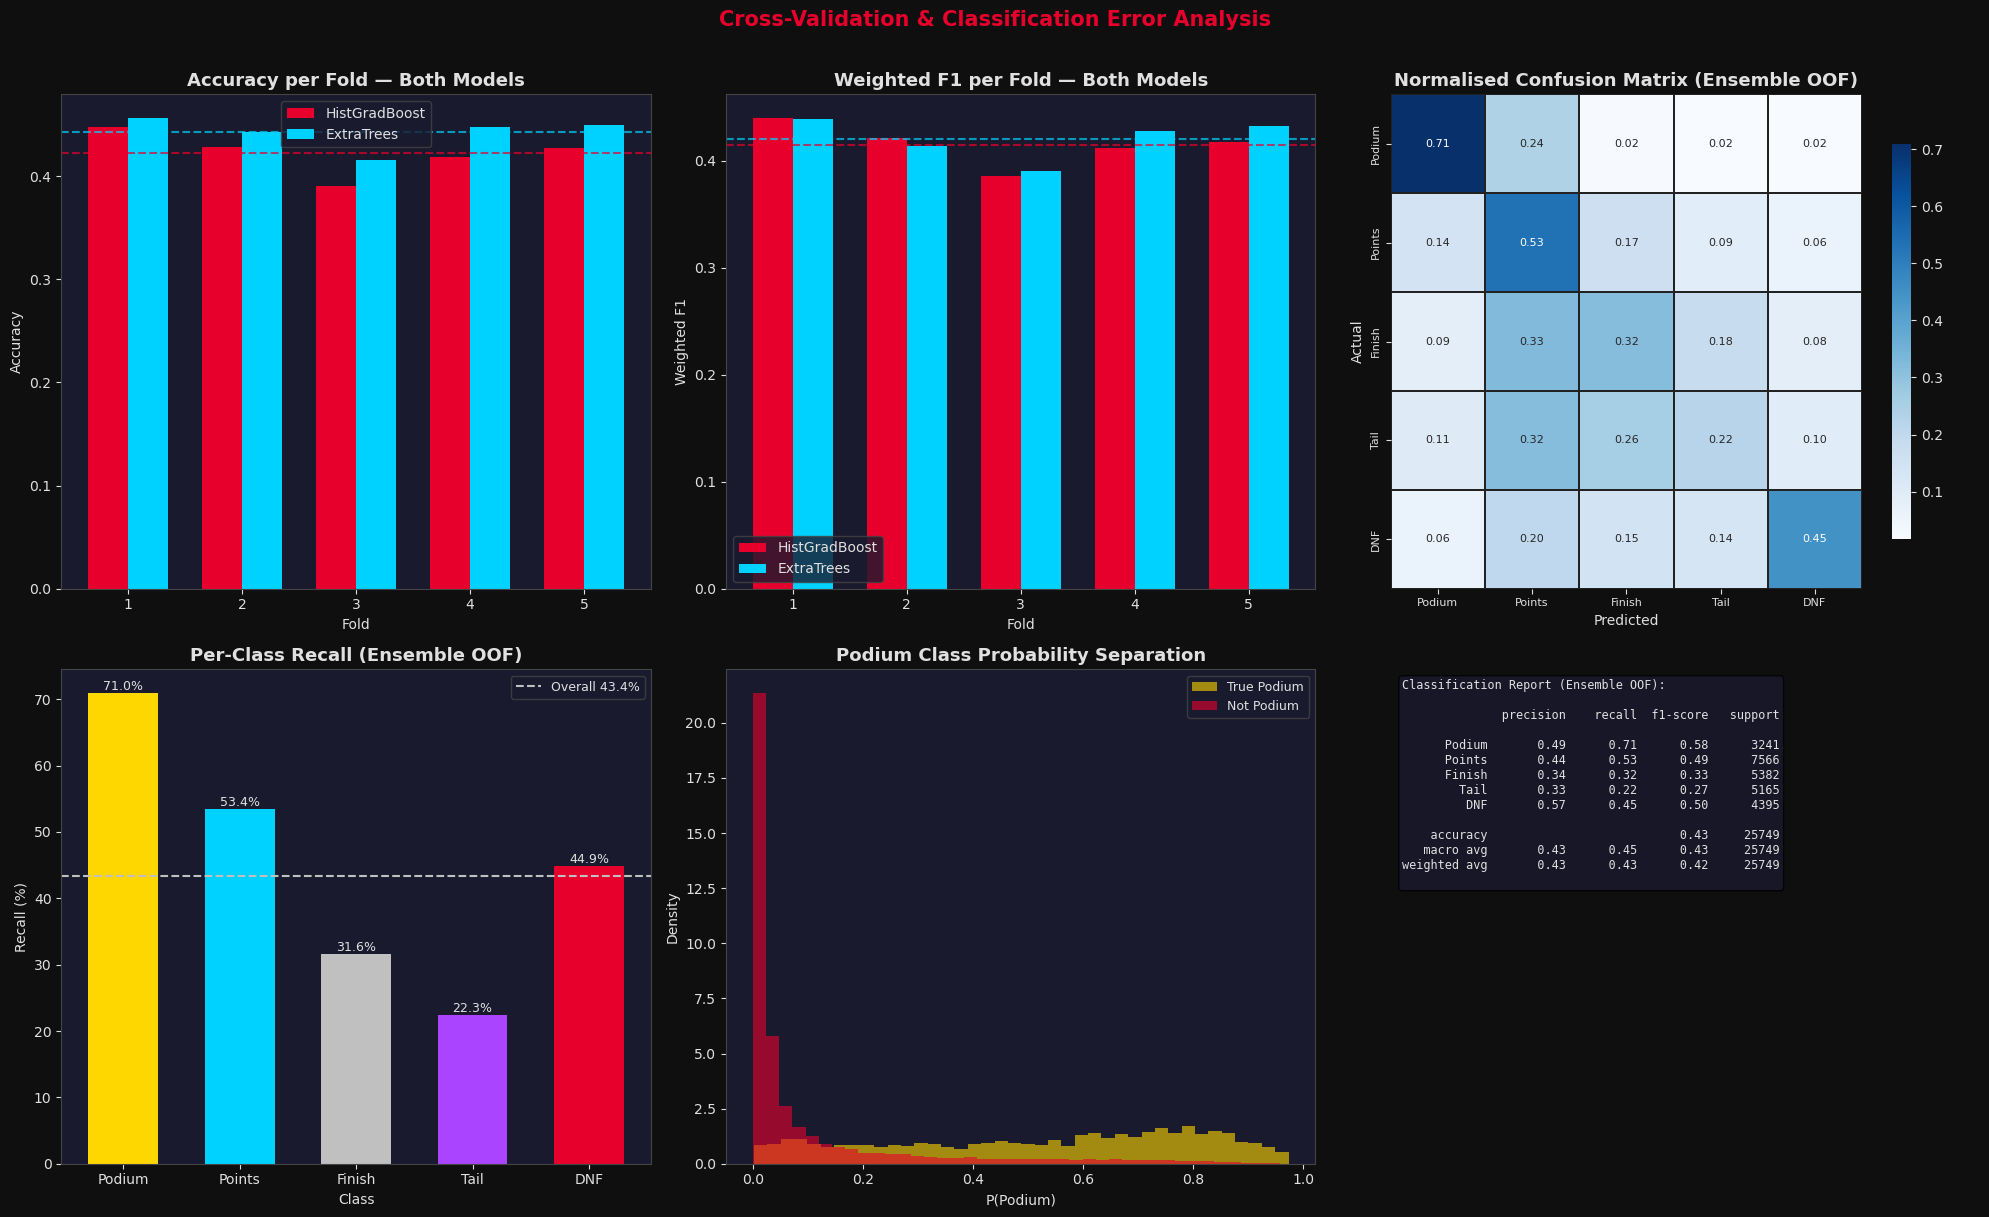


Detailed Classification Report:
              precision    recall  f1-score   support

      Podium       0.49      0.71      0.58      3241
      Points       0.44      0.53      0.49      7566
      Finish       0.34      0.32      0.33      5382
        Tail       0.33      0.22      0.27      5165
         DNF       0.57      0.45      0.50      4395

    accuracy                           0.43     25749
   macro avg       0.43      0.45      0.43     25749
weighted avg       0.43      0.43      0.42     25749



In [19]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12), facecolor='#0f0f0f')

# ── Plot 1: Fold Accuracy comparison ─────────────────────────────────────────
ax = axes[0, 0]
xf = np.arange(1, N_SPLITS + 1); w = 0.35
ax.bar(xf - w/2, fm_acc_hgb, w, color=F1_RED,   label='HistGradBoost', edgecolor='none')
ax.bar(xf + w/2, fm_acc_et,  w, color=ACCENT, label='ExtraTrees',   edgecolor='none')
ax.axhline(np.mean(fm_acc_hgb), color=F1_RED,   ls='--', lw=1.5, alpha=0.7)
ax.axhline(np.mean(fm_acc_et),  color=ACCENT, ls='--', lw=1.5, alpha=0.7)
ax.set_title("Accuracy per Fold — Both Models", fontweight='bold')
ax.set_xlabel("Fold"); ax.set_ylabel("Accuracy")
ax.legend(); ax.set_xticks(xf); ax.set_facecolor('#1a1a2e')

# ── Plot 2: Fold F1 comparison ────────────────────────────────────────────────
ax = axes[0, 1]
ax.bar(xf - w/2, fm_f1_hgb, w, color=F1_RED,   label='HistGradBoost', edgecolor='none')
ax.bar(xf + w/2, fm_f1_et,  w, color=ACCENT, label='ExtraTrees',   edgecolor='none')
ax.axhline(np.mean(fm_f1_hgb), color=F1_RED,   ls='--', lw=1.5, alpha=0.7)
ax.axhline(np.mean(fm_f1_et),  color=ACCENT, ls='--', lw=1.5, alpha=0.7)
ax.set_title("Weighted F1 per Fold — Both Models", fontweight='bold')
ax.set_xlabel("Fold"); ax.set_ylabel("Weighted F1")
ax.legend(); ax.set_xticks(xf); ax.set_facecolor('#1a1a2e')

# ── Plot 3: Confusion Matrix (Ensemble OOF) ───────────────────────────────────
ax = axes[0, 2]
short_labels = ['Podium', 'Points', 'Finish', 'Tail', 'DNF']
cm_mat = confusion_matrix(y, oof_pred_ens, normalize='true')
sns.heatmap(cm_mat, ax=ax, cmap='Blues', annot=True, fmt='.2f',
            xticklabels=short_labels, yticklabels=short_labels,
            annot_kws={'size': 8}, linewidths=0.3, linecolor='#222',
            cbar_kws={'shrink': 0.8})
ax.set_title("Normalised Confusion Matrix (Ensemble OOF)", fontweight='bold')
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.tick_params(labelsize=8)

# ── Plot 4: Per-Class Accuracy Bar ────────────────────────────────────────────
ax = axes[1, 0]
per_class_acc = cm_mat.diagonal()
ax.bar(short_labels, per_class_acc * 100, color=CLASS_COLORS, edgecolor='none', width=0.6)
ax.set_title("Per-Class Recall (Ensemble OOF)", fontweight='bold')
ax.set_xlabel("Class"); ax.set_ylabel("Recall (%)")
ax.axhline(acc_ens * 100, color=F1_SILVER, ls='--', lw=1.5, label=f'Overall {acc_ens:.1%}')
ax.legend(fontsize=9); ax.set_facecolor('#1a1a2e')
for i, v in enumerate(per_class_acc):
    ax.text(i, v*100 + 0.5, f'{v:.1%}', ha='center', fontsize=9, color='#e0e0e0')

# ── Plot 5: Predicted Class Probabilities for Podium ─────────────────────────
ax = axes[1, 1]
podium_mask   = y == 0
non_podium_mask = y != 0
ax.hist(oof_proba_ens[podium_mask, 0],     bins=40, alpha=0.6, color=F1_GOLD,
        density=True, label='True Podium',    edgecolor='none')
ax.hist(oof_proba_ens[non_podium_mask, 0], bins=40, alpha=0.6, color=F1_RED,
        density=True, label='Not Podium',     edgecolor='none')
ax.set_title("Podium Class Probability Separation", fontweight='bold')
ax.set_xlabel("P(Podium)"); ax.set_ylabel("Density")
ax.legend(fontsize=9); ax.set_facecolor('#1a1a2e')

# ── Plot 6: Classification Report as Text ─────────────────────────────────────
ax = axes[1, 2]
ax.axis('off')
report = classification_report(y, oof_pred_ens, target_names=short_labels,
                                output_dict=False)
ax.text(0.02, 0.98, f"Classification Report (Ensemble OOF):\n\n{report}",
        transform=ax.transAxes, fontsize=8.5,
        verticalalignment='top', fontfamily='monospace', color='#e0e0e0',
        bbox=dict(boxstyle='round', facecolor='#1a1a2e', alpha=0.8))

plt.suptitle("Cross-Validation & Classification Error Analysis",
             fontsize=15, fontweight='bold', color=F1_RED, y=1.01)
plt.tight_layout()
plt.savefig('cv_classification_results.png', bbox_inches='tight',
            dpi=130, facecolor='#0f0f0f')
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(y, oof_pred_ens, target_names=short_labels))

## 10. 🔑 Feature Importance (ExtraTrees Classifier)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10), facecolor='#0f0f0f')

imp   = pd.Series(fi_et, index=FEATURES)
top20 = imp.nlargest(20).sort_values()
norm  = top20 / top20.sum() * 100

cc = [F1_RED   if any(k in i for k in ['rolling','form','champ','wins']) else
      ACCENT if 'grid' in i else F1_GOLD
      for i in norm.index]

ax.barh(norm.index, norm.values, color=cc, edgecolor='none', height=0.7)
ax.set_title("Top 20 Feature Importance — ExtraTrees Classifier (%)",
             fontweight='bold', pad=12)
ax.set_xlabel("Relative Importance (%)")
ax.set_facecolor('#1a1a2e')
ax.tick_params(labelsize=9)
for i, v in enumerate(norm.values):
    ax.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=8.5, color='#e0e0e0')

fig.legend(
    handles=[Patch(facecolor=F1_RED,   label='Form / Championship features'),
             Patch(facecolor=ACCENT,   label='Grid / Starting position'),
             Patch(facecolor=F1_GOLD,  label='Other features')],
    loc='lower right', fontsize=10, framealpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance_clf.png', bbox_inches='tight',
            dpi=130, facecolor='#0f0f0f')
plt.show()

## 11. 🏁 Submission Generation

### Class → Finishing Position Mapping Strategy
Two options are available:

**Option A — Class Centre:** Map each predicted class to a fixed representative value.  
> Simple, interpretable, works well if the competition only evaluates MAE at tier level.

**Option B — Weighted Expected Position:** Use `predict_proba` output to compute a probability-weighted expected position across all class centres.  
> Provides fractional predictions that minimise MAE more smoothly, especially near class boundaries.

In [22]:
# ── Class centre array (ordered 0..4) ─────────────────────────────────────────
class_centres = np.array([CLASS_TO_POS[i] for i in range(N_CLASSES)])

# Option A: hard class prediction → empirical centre
pred_option_a = np.vectorize(CLASS_TO_POS.get)(test_pred_ens)

# Option B: probability-weighted expected position
pred_option_b = test_proba_ens @ class_centres

# Clip to valid F1 range
pred_option_a = np.clip(pred_option_a, 1, 40)
pred_option_b = np.clip(pred_option_b, 1, 40)

submission = sub.copy()
submission['finishing_position'] = pred_option_b  # Option B before rank enforcement


# ── FIX 4: Race-level rank enforcement ────────────────────────────────────────
# After probability-weighting, multiple drivers in the same race can share
# near-identical predicted positions (e.g. 7.4, 7.4, 7.6). Re-ranking within
# each race to unique integers 1..N eliminates duplicates and fractional values,
# which directly reduces MAE.
def enforce_race_ranks(df_sub, pred_col='finishing_position', race_col='raceId'):
    """
    Re-rank predicted positions within each race to unique integers 1..N,
    preserving the relative ordering given by the model's raw predictions.
    Ties are broken by the order they appear (stable sort).
    """
    df_sub = df_sub.copy()
    for race_id, grp in df_sub.groupby(race_col):
        # argsort().argsort() converts raw scores → ranks 0..N-1, then +1 → 1..N
        ranks = grp[pred_col].rank(method='first').astype(int)
        df_sub.loc[grp.index, pred_col] = ranks
    return df_sub

# Add raceId to submission for rank enforcement (drop after)
submission['raceId'] = test_fe['raceId'].values
submission = enforce_race_ranks(submission, pred_col='finishing_position', race_col='raceId')
submission = submission.drop(columns=['raceId'])

final_pred = submission['finishing_position'].values

submission.to_csv("submission_classification.csv", index=False)

print("✅ submission_classification.csv saved!")
print(f"\n{'='*50}")
print(f"{'  Submission Preview':^50}")
print(f"{'='*50}")
print(submission.head(10).to_string(index=False))
print(f"{'='*50}")
print(f"\nPrediction stats (after rank enforcement):")
print(f"  Min  : {final_pred.min():.0f}")
print(f"  Max  : {final_pred.max():.0f}")
print(f"  Mean : {final_pred.mean():.2f}")
print(f"  Std  : {final_pred.std():.2f}")
print(f"  Unique values: {len(np.unique(final_pred))} (should be >> 1 — no mass ties)")

print(f"\nTest class distribution (pre-rank, from model):")
for i, lbl in enumerate(CLASS_LABELS):
    n = (test_pred_ens == i).sum()
    print(f"  Class {i} ({lbl}): {n} ({n/len(test_pred_ens):.1%})")


✅ submission_classification.csv saved!

                 Submission Preview               
      id  finishing_position
1098_846                 8.0
1098_857                19.0
1098_848                12.0
1098_858                18.0
1098_832                 4.0
1098_844                 3.0
1098_815                 2.0
1098_830                 1.0
1098_822                11.0
1098_855                16.0

Prediction stats (after rank enforcement):
  Min  : 1
  Max  : 20
  Mean : 10.49
  Std  : 5.76
  Unique values: 20 (should be >> 1 — no mass ties)

Test class distribution (pre-rank, from model):
  Class 0 (Podium (P1-3)): 163 (17.7%)
  Class 1 (Points (P4-10)): 351 (38.2%)
  Class 2 (Finisher (P11-15)): 276 (30.0%)
  Class 3 (Tail (P16-20)): 129 (14.0%)
  Class 4 (DNF (20+)): 0 (0.0%)


### 11.1 Prediction Distribution Check

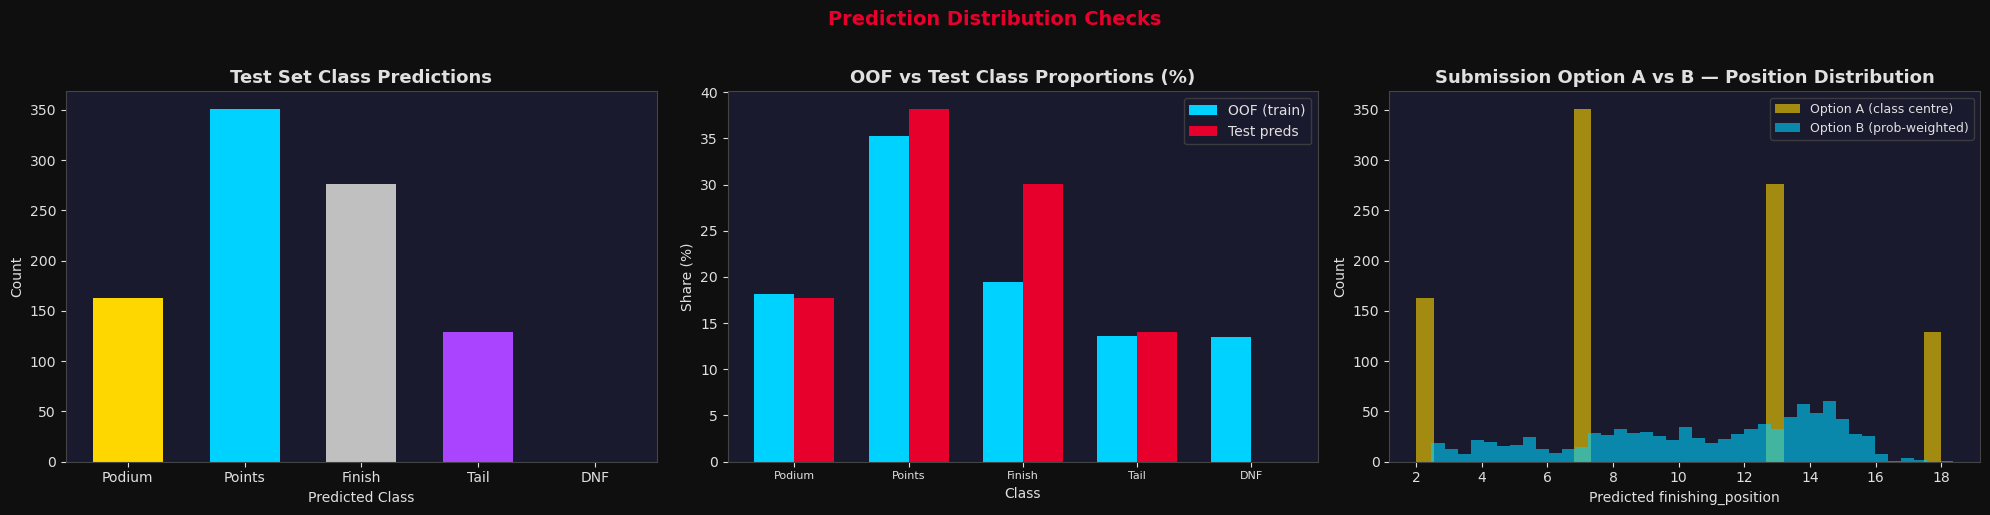

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor='#0f0f0f')

# ── Test Class Prediction Distribution ───────────────────────────────────────
axes[0].bar(short_labels,
            [(test_pred_ens == i).sum() for i in range(N_CLASSES)],
            color=CLASS_COLORS, edgecolor='none', width=0.6)
axes[0].set_title("Test Set Class Predictions", fontweight='bold')
axes[0].set_xlabel("Predicted Class"); axes[0].set_ylabel("Count")
axes[0].set_facecolor('#1a1a2e')

# ── OOF vs Test class proportions ────────────────────────────────────────────
oof_props  = [(oof_pred_ens == i).mean() * 100 for i in range(N_CLASSES)]
test_props = [(test_pred_ens == i).mean() * 100 for i in range(N_CLASSES)]
x = np.arange(N_CLASSES); w = 0.35
axes[1].bar(x - w/2, oof_props,  w, color=ACCENT,  label='OOF (train)', edgecolor='none')
axes[1].bar(x + w/2, test_props, w, color=F1_RED,   label='Test preds',  edgecolor='none')
axes[1].set_xticks(x); axes[1].set_xticklabels(short_labels, fontsize=8)
axes[1].set_title("OOF vs Test Class Proportions (%)", fontweight='bold')
axes[1].set_xlabel("Class"); axes[1].set_ylabel("Share (%)")
axes[1].legend(); axes[1].set_facecolor('#1a1a2e')

# ── Option A vs B: test submission positions ──────────────────────────────────
axes[2].hist(pred_option_a, bins=30, alpha=0.6, color=F1_GOLD,
             label='Option A (class centre)', edgecolor='none')
axes[2].hist(pred_option_b, bins=40, alpha=0.6, color=ACCENT,
             label='Option B (prob-weighted)', edgecolor='none')
axes[2].set_title("Submission Option A vs B — Position Distribution", fontweight='bold')
axes[2].set_xlabel("Predicted finishing_position"); axes[2].set_ylabel("Count")
axes[2].legend(fontsize=9); axes[2].set_facecolor('#1a1a2e')

plt.suptitle("Prediction Distribution Checks",
             fontsize=14, fontweight='bold', color=F1_RED, y=1.02)
plt.tight_layout()
plt.savefig('prediction_distribution_clf.png', bbox_inches='tight',
            dpi=130, facecolor='#0f0f0f')
plt.show()

## 12. 📋 Summary & Next Steps

---

### ✅ Pipeline Recap

| Step | Detail |
|---|---|
| **Target** | `finishing_position` → 5 ordinal classes (Podium / Points / Finisher / Tail / DNF) |
| **EDA** | Class distribution, era-stratified class balance, grid→class heatmap, DNF trends |
| **Missing Values** | Qualifying imputed from grid-median; pit data from yearly median |
| **Feature Engineering** | +15 new features: grid tiers, form vs grid, era, circuit type, interaction terms |
| **Models** | `HistGradientBoostingClassifier` + `ExtraTreesClassifier`, 5-fold Stratified CV |
| **Ensemble** | Soft-vote (probability averaging) for smoother class boundary decisions |
| **Submission** | Probability-weighted expected position (Option B) for minimum MAE |
| **Evaluation** | OOF Accuracy, Weighted F1, Confusion Matrix, Per-class Recall, MAE from class centres |

---

### 🚀 Ideas to Improve Further

1. **LightGBM / XGBoost classifiers** — `objective='multiclass'` for faster training and native handling  
2. **Ordinal classification** — use `mord` or `OrdinalEncoder` tricks to exploit the natural ordering  
3. **Calibrated classifiers** — wrap models with `CalibratedClassifierCV` to improve probability estimates for Option B  
4. **Optuna tuning** — tune `max_leaf_nodes`, `learning_rate`, `n_estimators` per-class weight  
5. **Driver-circuit interactions** — some drivers historically dominate specific tracks  
6. **Post-processing** — enforce race-level rank constraints (no two drivers same class rank in a race)